## SVM - Coral Bleaching Classification
**Dataset:** Galapagos Islands \
**Model:** Support Vector Machine (SVC, linear kernel) \
**Target:** Bleaching Alert Area (classes 0-4)

In [91]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize # required: SVM is distance-based, RF/XGBoost are not
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
# 1. LOAD THE DATA
file_path = '../data/galapagos_islands.csv'
data = pd.read_csv(file_path)

required_columns = [
    'Date', 'Latitude', 'Longitude',
    'Sea_Surface_Temperature', 'HotSpots',
    'Degree_Heating_Weeks', 'Bleaching_Alert_Area'
]
for col in required_columns:
    if col not in data.columns:
        raise ValueError(f"Missing column: {col}")

# Quick preview
print("Data preview:\n", data.head(), "\n")

# Class distribution
print("Class distribution:\n", data['Bleaching_Alert_Area'].value_counts().sort_index())

Data preview:
      Date  Latitude  Longitude  Sea_Surface_Temperature  HotSpots  \
0  1/1/85      0.15    -90.625                    23.83       0.0   
1  1/2/85      0.15    -90.625                    23.90       0.0   
2  1/3/85      0.15    -90.625                    23.94       0.0   
3  1/4/85      0.15    -90.625                    23.45       0.0   
4  1/5/85      0.15    -90.625                    23.62       0.0   

   Degree_Heating_Weeks  Bleaching_Alert_Area  
0                   0.0                     0  
1                   0.0                     0  
2                   0.0                     0  
3                   0.0                     0  
4                   0.0                     0   

Class distribution:
 Bleaching_Alert_Area
0    10465
1     1816
2      846
3      479
4     1055
Name: count, dtype: int64


In [93]:
# 2. SPLIT FEATURES (X) AND TARGET (y)
# Drop date (timestamp, not a predictive feature), latitude/longitude (fixed location, non-predictive), and target variable from features df
X = data.drop(columns=["Date", "Latitude", "Longitude", "Bleaching_Alert_Area"])
y = data["Bleaching_Alert_Area"]

# 3. SCALE THE FEATURES
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [94]:
# 5. TRAIN SVC WITH PROBABILITIES ENABLED
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# 6. PREDICT
y_pred = svm_model.predict(X_test)

Training accuracy: 0.9096
Test accuracy: 0.9015

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      2087
           1       0.72      0.44      0.55       365
           2       0.89      0.77      0.82       175
           3       0.97      0.66      0.79        89
           4       0.93      0.94      0.93       217

    accuracy                           0.90      2933
   macro avg       0.88      0.76      0.81      2933
weighted avg       0.89      0.90      0.89      2933



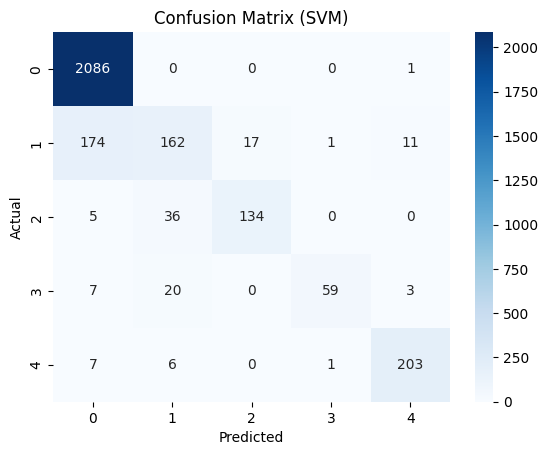

In [95]:
# 7. EVALUATION: ACCURACY, CLASS REPORT, CONFUSION MATRIX
train_accuracy = accuracy_score(y_train, svm_model.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualize confusion matrix with heatmap 
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SVM)")
plt.show()

In [96]:
# 8. CROSS-VALIDATION
cv_scores = cross_val_score(svm_model, X_scaled, y, cv=5, scoring='accuracy')
print(f"Cross-validation accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Cross-validation accuracy: 0.9093 (+/- 0.0119)


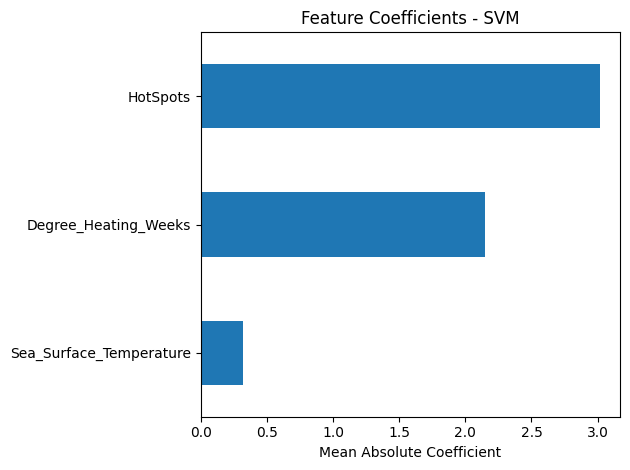

In [112]:
# 9. FEATURE COEFFICIENTS
feat_coefs = pd.Series(
    np.abs(svm_model.coef_).mean(axis=0),
    index=X.columns
)
feat_coefs.sort_values().plot(kind='barh')
plt.title("Feature Coefficients - SVM")
plt.xlabel("Mean Absolute Coefficient")
plt.tight_layout()
plt.show()


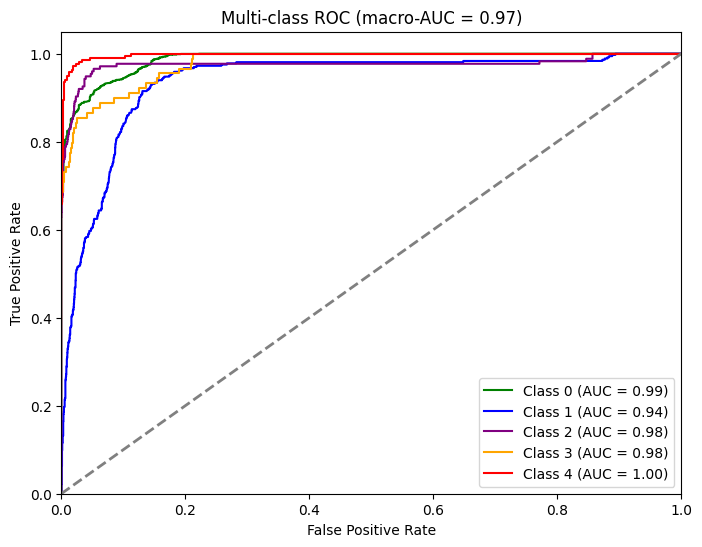

In [113]:
# 10. ROC CURVE & AUC FOR MULTI-CLASS (One-vs-Rest)
# Binarize the test labels for OvR metrics
y_test_bin = label_binarize(y_test, classes=svm_model.classes_)

# Get probability estimates (shape: [n_samples, n_classes])
y_pred_proba = svm_model.predict_proba(X_test)

# For storing fpr, tpr, roc_auc for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = len(svm_model.classes_)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute macro-average ROC curve/ROC AUC
# Interpolate all ROC curves at distinct points
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Average and compute AUC
mean_tpr /= n_classes
roc_auc_macro = auc(all_fpr, mean_tpr)

# Plot ROC curves for each class, label with class and AUC value
plt.figure(figsize=(8, 6))
colors = ['green', 'blue', 'purple', 'orange', 'red']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=1.5,
              label=f"Class {svm_model.classes_[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="gray")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title(f"Multi-class ROC (macro-AUC = {roc_auc_macro:.2f})")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

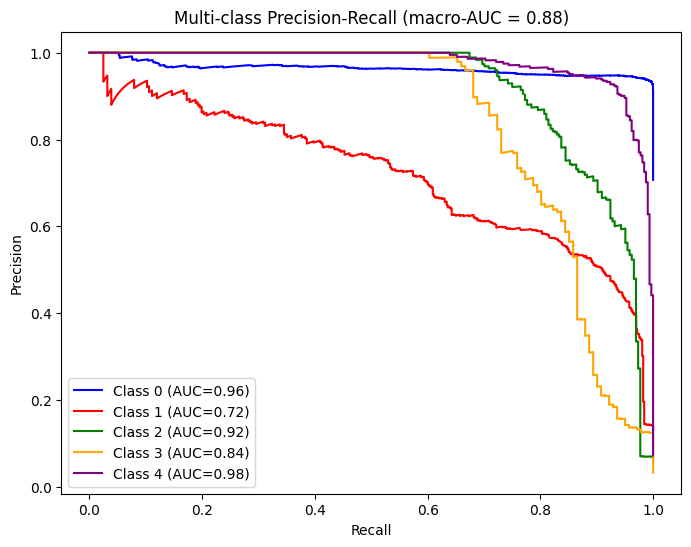

In [ ]:
# 11. PRECISION-RECALL CURVE (One-vs-Rest)
precision = dict()
recall = dict()
pr_auc = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    pr_auc[i] = auc(recall[i], precision[i])

# Macro-average for PR
all_recall = np.unique(np.concatenate([recall[i] for i in range(n_classes)]))
mean_precision = np.zeros_like(all_recall)
for i in range(n_classes):
    mean_precision += np.interp(all_recall, recall[i][::-1], precision[i][::-1])
mean_precision /= n_classes
pr_auc_macro = auc(all_recall, mean_precision)

# Plot the one-vs-rest Precision-Recall curves
plt.figure(figsize=(8, 6))
colors = ['green', 'blue', 'purple', 'orange', 'red']
for i, color in zip(range(n_classes), colors):
    plt.plot(recall[i], precision[i], color=color, lw=1.5,
             label=f"Class {svm_model.classes_[i]} (AUC={pr_auc[i]:.2f})")

plt.title(f"Multi-class Precision-Recall (macro-AUC = {pr_auc_macro:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()
